# Измерение коэффициента ослабления потока $\gamma$-лучей в веществе и определение их энергии.

In [141]:
import sys
sys.path.append('../../')
sys.path.append('/home/netort/sanya_labs/5.5.1/')

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import math

from lab_lib import *

from scipy.optimize import curve_fit

from common import *

### измерение длин дисков

In [142]:
l_al = [2.10, 2.22, 2.00, 2.12, 2.30, 2.00, 2.00, 2.20, 2.00] # cm
l_pb = [0.48, 0.50, 0.50, 0.50, 0.45, 0.49, 0.46, 0.47, 0.52] # cm
l_fe = [10.2, 10.2, 10.1, 10.2, 10.2, 9.90, 10.2, 10.1, 10.2, 10.1] # mm
l_fe = l_fe[0:-1]

l_al = [l / 100 for l in l_al]
l_pb = [l / 100 for l in l_pb]
l_fe = [l / 1000 for l in l_fe]

In [143]:
# MeV
E_photon = [0.3,     0.4,   0.5,   0.6,   0.7,   0.8,   0.9,   1.0,   1.1]
# 1/cm
Al_mu =    [0.281, 0.250, 0.228, 0.210, 0.196, 0.184, 0.175, 0.166, 0.158]
Fe_mu =    [0.866, 0.740, 0.662, 0.606, 0.563, 0.528, 0.498, 0.472, 0.450]
Pb_mu =    [ 4.57, 2.63,  1.83,  1.42,  1.17,  1.01, 0.891, 0.806, 0.740]

In [144]:
sigma_N = 1000
sigma_t = 0.1 # sec
sigma_l = 0.02 * 1e-3 # m

### измерение фона

In [145]:
background_t = 3 * 60 # sec
background_N = 4005
bg_per_sec = background_N / background_t
I_bg = bg_per_sec

latex_measurement(r"$I_\text{фон}$", I_bg, sigma_N / background_t, "соб/сек")

$$I_\text{фон}$ = (2.225 \pm 0.556)\ \times 10^{1} ~\text{соб/сек} \ (\varepsilon \approx 24.969\ \%)$


### измерение N_0

In [146]:
initial_t = 20 # sec
initial_N = 189186 
init_per_sec = initial_N / initial_t - bg_per_sec
I_0 = init_per_sec
latex_measurement(r"$I_0$", I_0, sigma_N / initial_t, "c^{-1}")

$$I_0$ = (9.437 \pm 0.050)\ \times 10^{3} ~\text{c^{-1}} \ (\varepsilon \approx 0.530\ \%)$


## Алюминий

In [147]:
l = [l_al[0], sum(l_al[0:2]), sum(l_al[0:3]), sum(l_al[0:4]), sum(l_al[0:5]), sum(l_al[0:6]), sum(l_al[0:7]), sum(l_al[0:8]), sum(l_al[0:9])]
t = [     15,              40,            40,        20 + 80,             90,            130,            170,            180,            180]
N = [  93799,   83595 + 83472, 55801 + 55908, 37289 + 149533,         113937,  85566 + 25443,  11534 + 87784,          73164,          52175]

I = [round(n / t - bg_per_sec, 1) for n, t in zip(N, t)]
I_al = I
l, t, N, I

([0.021, 0.0432, 0.0632, 0.0844, 0.1074, 0.1274, 0.1474, 0.1694, 0.1894],
 [15, 40, 40, 100, 90, 130, 170, 180, 180],
 [93799, 167067, 111709, 186822, 113937, 111009, 99318, 73164, 52175],
 [6231.0, 4154.4, 2770.5, 1846.0, 1243.7, 831.7, 562.0, 384.2, 267.6])

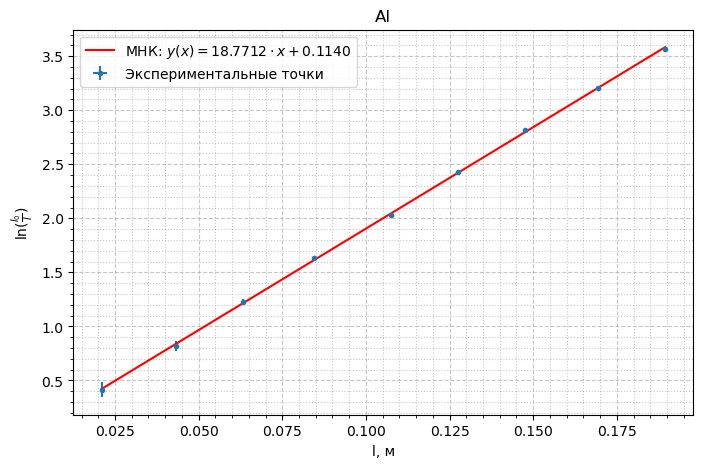

$mu = (1.877 \pm 0.011)\ \times 10^{1} ~\text{см^-1} \ (\varepsilon \approx 0.607\ \%)$


In [148]:
k, b, kerr, berr = linear_graph(l, [np.log(I_0 / i) for i in I], [sigma_l * np.sqrt(i) for i in range(len(l))], [n * sigma_N / t / I_0**2  for n, t in zip(N,t)], "l, м", r"ln($\frac{I_0}{I}$)", "Al")
latex_measurement("mu", k, kerr, "см^-1")

Al_mu_experiment = (k, kerr)

## Свинец

In [149]:
l = [l_pb[0], sum(l_pb[0:2]), sum(l_pb[0:3]), sum(l_pb[0:4]), sum(l_pb[0:5]), sum(l_pb[0:6]), sum(l_pb[0:7]), sum(l_pb[0:8]), sum(l_pb[0:9])]
t = [     20,           30,               60,             90,            120,            180,            180,            180,            180]
N = [ 108949,        95576,           110763,          90796,          71093,          63972,          41747,          27693,          19296]

I = [round(n / t - bg_per_sec, 1) for n, t in zip(N, t)]
I_pb = I

l, t, N, I

([0.0048,
  0.0098,
  0.0148,
  0.019799999999999998,
  0.024300000000000002,
  0.0292,
  0.0338,
  0.0385,
  0.0437],
 [20, 30, 60, 90, 120, 180, 180, 180, 180],
 [108949, 95576, 110763, 90796, 71093, 63972, 41747, 27693, 19296],
 [5425.2, 3163.6, 1823.8, 986.6, 570.2, 333.1, 209.7, 131.6, 85.0])

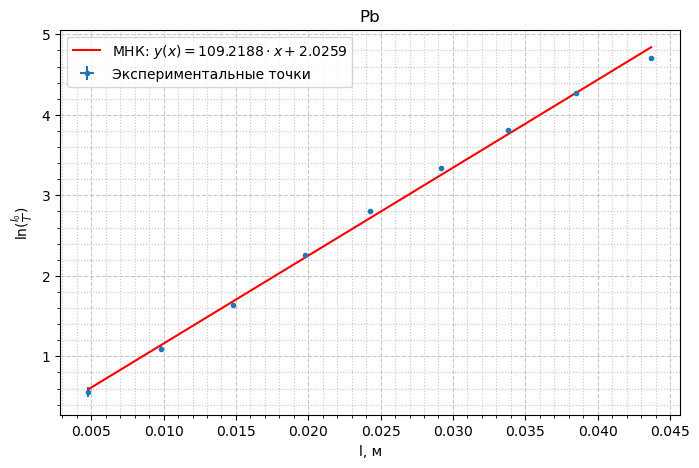

$mu = (1.092 \pm 0.020)\ \times 10^{2} ~\text{см^-1} \ (\varepsilon \approx 1.855\ \%)$


In [150]:
k, b, kerr, berr = linear_graph(l, [np.log(I_0 / i) for i in I], [sigma_l * np.sqrt(i) for i in range(len(l))], [n * sigma_N / t / I_0**2 for n, t in zip(N,t)], "l, м", r"ln($\frac{I_0}{I}$)", "Pb")
latex_measurement("mu", k, kerr, "см^-1")
Pb_mu_experiment = (k, kerr)

## Железо

In [151]:
l = [l_fe[0], sum(l_fe[0:2]), sum(l_fe[0:3]), sum(l_fe[0:4]), sum(l_fe[0:5]), sum(l_fe[0:6]), sum(l_fe[0:7]), sum(l_fe[0:8]), sum(l_fe[0:9])]
t = [     20,           30,               60,             90,            160,            180,            180,            180,            180]
N = [ 108668,        92876,    17740 + 89412,  15417 + 77266,  24020 + 72897,          65343,          40559,          26867,          18826]

I = [round(n / t - bg_per_sec, 1) for n, t in zip(N, t)]
I_fe = I
l, t, N, I

([0.010199999999999999,
  0.020399999999999998,
  0.0305,
  0.0407,
  0.050899999999999994,
  0.06079999999999999,
  0.071,
  0.08109999999999999,
  0.09129999999999999],
 [20, 30, 60, 90, 160, 180, 180, 180, 180],
 [108668, 92876, 107152, 92683, 96917, 65343, 40559, 26867, 18826],
 [5411.1, 3073.6, 1763.6, 1007.6, 583.5, 340.8, 203.1, 127.0, 82.3])

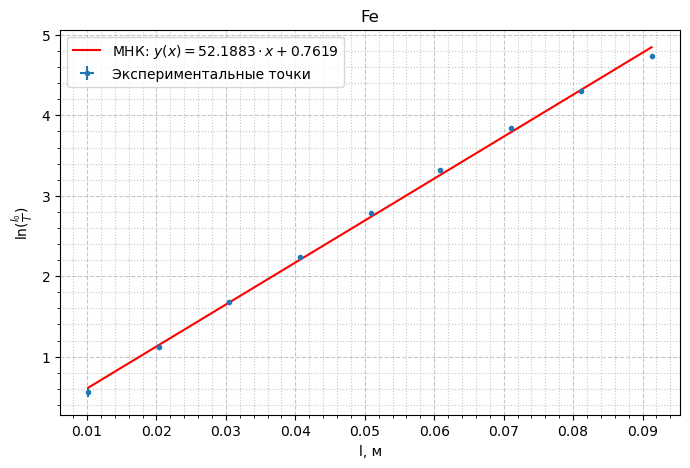

$mu = (5.219 \pm 0.076)\ \times 10^{1} ~\text{см^-1} \ (\varepsilon \approx 1.460\ \%)$


In [152]:
k, b, kerr, berr = linear_graph(l, [np.log(I_0 / i) for i in I], [sigma_l * np.sqrt(i) for i in range(len(l))], [n * sigma_N / t / I_0**2 for n, t in zip(N,t)], "l, м", r"ln($\frac{I_0}{I}$)", "Fe")
latex_measurement("mu", k, kerr, "см^-1")
Fe_mu_experiment = (k, kerr)

$$E_{Al} = (7.740 \pm 1.405)\ \times 10^{-1} ~\text{МэВ} \ (\varepsilon \approx 18.153\ \%)$
$$E_{Fe} = (8.112 \pm 1.771)\ \times 10^{-1} ~\text{МэВ} \ (\varepsilon \approx 21.828\ \%)$
$$E_{Pb} = (7.602 \pm 0.483)\ \times 10^{-1} ~\text{МэВ} \ (\varepsilon \approx 6.350\ \%)$


<>:76: SyntaxWarning: invalid escape sequence '\p'
<>:76: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_111675/3500028396.py:76: SyntaxWarning: invalid escape sequence '\p'
  plt.errorbar(y=E_, x=mu_exp[0], yerr=E_sigma_, xerr=mu_exp[1], fmt='s', markersize=6, label = f'$\\mu_{{{ materials[i] }}}$ = ({ round(mus_experiment[i][0], 3) } $\pm$ { round(mus_experiment[i][1], 3) }) см$^{{-1}}$')


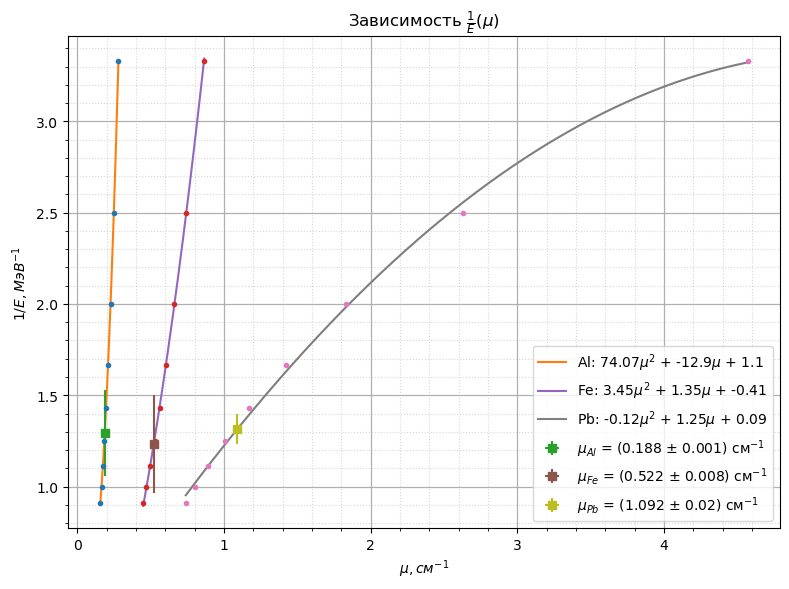



\begin{table}[!ht]
    \centering
    \begin{tabular}{|c|c|c|c|}
        \hline

         & Pb & Fe & Al\\ \hline
        a & $74 \pm 2$ & $3.4 \pm 0.3$ & $-0.118 \pm 0.010$\\ \hline
        b & $-13 \pm 1$ & $1.3 \pm 0.4$ & $1.25 \pm 0.06$\\ \hline
        c & $1.10 \pm 0.11$ & $-0.4 \pm 0.1$ & $0.09 \pm 0.05$\\ \hline

    \end{tabular}
    \caption{}
    \label{}
\end{table}



In [153]:
def func(x, a, b, c):
    return a*x**2 + b*x + c

def func_inacc(x, dx, a, b, c, da, db, dc):
    inacc_ = [(2*a*x + b)*dx, da*x**2, db*x, dc]
    return np.sqrt(sum([i**2 for i in inacc_]))

def func4(x, a, b, c, d, e):
    return a*x**4 + b*x**3 + c*x**2 + d*x + e

def func4_inacc(x, dx, a, b, c, d, e, da, db, dc, dd, de):
    inacc_ = [(4*a*x**3 + 3*b*x**2 + 2*c*x + d) * dx, da*x**4, db*x**3, dc*x**2, dd*x, de]
    return np.sqrt(sum([i**2 for i in inacc_]))

def func3(x, a, b, c, d):
    return a*x**3 + b*x**2 + c*x + d

def func3_inacc(x, dx, a, b, c, d, da, db, dc, dd):
    inacc_ = [(3*a*x**2 + 2*b*x + c*x + d) * dx, da*x**3, db*x**2, dc*x, dd]
    return np.sqrt(sum([i**2 for i in inacc_]))

def calc(coeffs, x):
    deg = len(coeffs) - 1
    ans = 0
    for k in coeffs:
        ans += k*x**deg
        deg -= 1
    return ans

# plt.figure(figsize = (12,8), facecolor = "white")
plt.figure(figsize=(8, 6))
plt.title(r"Зависимость $\frac{1}{E}(\mu)$")
plt.ylabel(r"$1/E, МэВ^{-1}$")
plt.xlabel(r"$\mu, см^{-1}$")

# Al_mu = Al_mu[1:]
# Pb_mu = Pb_mu[1:]
# Fe_mu = Fe_mu[1:]
# E_photon = E_photon[1:]


mus = [Pb_mu, Fe_mu, Al_mu]
mus_experiment = [Pb_mu_experiment, Fe_mu_experiment, Al_mu_experiment]
mus_experiment = [(m[0] / 100, m[1] / 100) for m in mus_experiment]
materials = ["Pb", "Fe", "Al"]
Es = []

funcs = [func]*3
funcs_inacc = [func_inacc]*3

coefficients = []

for i in range(len(mus)-1, -1, -1):
    mu = [i for i in mus[i]]
    mu_exp = mus_experiment[i]

    # popt, pcov = curve_fit(funcs[i], mu, [1/j for j in E_photon])
    popt, pcov = np.polyfit(mu, [1/j for j in E_photon], deg=2, cov=True)
    coeffs  = popt
    dcoeffs = np.sqrt(np.diag(pcov))

    coefficients.append([(coeffs[i], dcoeffs[i]) for i in range(len(coeffs))])

    plt.errorbar(mu, [1/j for j in E_photon], fmt='.')

    x_lin = np.linspace(min(mu), max(mu), 1000)
    plt.plot(x_lin, [calc(coeffs, x) for x in x_lin], label = materials[i] + ": "
                                                            + str(round(coeffs[0], 2)) + r"$\mu^2$ + "
                                                            + str(round(coeffs[1], 2))+ r"$\mu$ + "
                                                            + str(round(coeffs[2], 2)))

    E_ = calc(coeffs=coeffs, x=mu_exp[0])
    E_sigma_ = func_inacc(mu_exp[0], mu_exp[1], *coeffs, *dcoeffs)
    E = (1/E_, E_sigma_/E_**2)

    plt.errorbar(y=E_, x=mu_exp[0], yerr=E_sigma_, xerr=mu_exp[1], fmt='s', markersize=6, label = f'$\\mu_{{{ materials[i] }}}$ = ({ round(mus_experiment[i][0], 3) } $\pm$ { round(mus_experiment[i][1], 3) }) см$^{{-1}}$')

    latex_measurement(r"$E_{" + materials[i] + "}", E[0], E[1], "МэВ")
    Es.append(E)

plt.grid(visible = True, which = 'major', axis = 'both', alpha = 1,   linewidth = 0.9) # Активируем сетку
plt.grid(visible = True, which = 'minor', axis = 'both', alpha = 0.5, linestyle = ':')

plt.minorticks_on()
plt.tight_layout()
plt.legend() # Активируем легенду графика

plt.savefig("img/attenuation_factor_plot.png")
plt.show()

coeffs_names = "abcdefghijkl"
coeffs_table = [[""] + materials]
for i in range(len(coefficients[0])):
    coeffs_table.append([coeffs_names[i]] + [texAns(j[i]) for j in coefficients])

texTable(coeffs_table)

In [154]:
latex_measurement(r"\langle E \rangle", np.mean([e[0] for e in Es]), np.sqrt(np.sum([i[1]**2 for i in Es])), "МэВ")

$\langle E \rangle = (7.818 \pm 2.311)\ \times 10^{-1} ~\text{МэВ} \ (\varepsilon \approx 29.565\ \%)$


In [155]:
rhos = [11.35, 7.87, 2.70]

mu1 = [mus_experiment[i][0] / rhos[i] for i in range(len(rhos))]
sigmaaaaaa = [mus_experiment[j][1] / rhos[j] for j in range(len(rhos))]
for i in range(len(materials)):
    latex_measurement("" + materials[i] + ": " + r"\mu'", mu1[i], sigmaaaaaa[i], "см^2/г")

$Pb: \mu' = (9.623 \pm 0.178)\ \times 10^{-2} ~\text{см^2/г} \ (\varepsilon \approx 1.855\ \%)$
$Fe: \mu' = (6.631 \pm 0.097)\ \times 10^{-2} ~\text{см^2/г} \ (\varepsilon \approx 1.460\ \%)$
$Al: \mu' = (6.952 \pm 0.042)\ \times 10^{-2} ~\text{см^2/г} \ (\varepsilon \approx 0.607\ \%)$
